In [ ]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from google.colab import drive
drive.mount('/content/drive')
diretorio = '/content/drive/MyDrive/Introd. a Ciência de Dados/dados_cd'

Mounted at /content/drive


In [ ]:
# Configuração do estilo
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Lista de arquivos disponíveis
anos_disponiveis = []
for ano in range(2015, 2025):
    if glob.glob(f'{diretorio}/datatran{ano}.csv'):
        anos_disponiveis.append(ano)

#print(f"Anos disponíveis para análise: {anos_disponiveis}")

# Carregar dados de todos os anos disponíveis
dfs = []
for ano in anos_disponiveis:
    try:
        df_ano = pd.read_csv(f'{diretorio}/datatran{ano}.csv', sep=';', encoding='latin-1', low_memory=False)
        df_ano['ano'] = ano  # Adicionar coluna de ano
        dfs.append(df_ano)
        #print(f"Dados de {ano} carregados: {len(df_ano)} registros")
    except Exception as e:
        print(f"Erro ao carregar {ano}: {e}")

# Combinar todos os dados em um único DataFrame
df = pd.concat(dfs, ignore_index=True)
print(f"\nDataset combinado: {df.shape}")

# Pré-processamento dos dados
df['data_inversa'] = df['data_inversa'].str.replace('/', '-', regex=False)

# "Ajeitando as datas de 2016"
df.loc[df['ano'] == 2016, 'data_inversa'] = pd.to_datetime(df.loc[df['ano'] == 2016, 'data_inversa'],
                                                            format='%d-%m-%y',
                                                            errors='coerce')
df['data_inversa'] = pd.to_datetime( df['data_inversa'], errors='coerce')

df


Dataset combinado: (778662, 31)


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,83298209.0,2015-01-01,Quinta,00:05:00,RJ,101,327.0,NITEROI,Outras,Colisão traseira,...,0,2,0,0,2,NaN,NaN,NaN,NaN,NaN
1,83298218.0,2015-01-01,Quinta,01:20:00,MS,163,434.4,CAMPO GRANDE,Animais na Pista,Saída de Pista,...,0,1,0,1,1,NaN,NaN,NaN,NaN,NaN
2,83298220.0,2015-01-01,Quinta,01:45:00,RJ,40,64.0,PETROPOLIS,Outras,Colisão com objeto fixo,...,0,2,0,0,2,NaN,NaN,NaN,NaN,NaN
3,83298221.0,2015-01-01,Quinta,02:50:00,SC,101,356.1,SANGAO,Falta de atenção,Saída de Pista,...,0,0,0,4,1,NaN,NaN,NaN,NaN,NaN
4,83298222.0,2015-01-01,Quinta,02:50:00,RS,101,25.9,TRES CACHOEIRAS,Falta de atenção,Saída de Pista,...,0,1,0,0,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
778657,661295.0,2024-12-21,sábado,07:00:00,PB,230,"135,2",CAMPINA GRANDE,Ausência de reação do condutor,Saída de leito carroçável,...,0,0,0,1,1,-7.282103,-35.768394,SPRF-PB,DEL02-PB,UOP01-DEL02-PB
778658,661307.0,2024-12-01,domingo,06:30:00,RJ,393,298,VOLTA REDONDA,Ausência de reação do condutor,Colisão frontal,...,0,0,0,2,2,-22.543133,-44.112986,SPRF-RJ,DEL07-RJ,UOP02-DEL07-RJ
778659,661377.0,2024-07-09,terça-feira,16:20:00,ES,101,"101,5",SOORETAMA,Desrespeitar a preferência no cruzamento,Colisão transversal,...,0,0,0,3,2,-18.988339,-39.999335,SPRF-ES,DEL04-ES,UOP02-DEL04-ES
778660,661576.0,2024-12-17,terça-feira,21:35:00,RJ,101,391,RIO DE JANEIRO,Frear bruscamente,Colisão traseira,...,0,1,0,1,2,-22.894827,-43.68492,SPRF-RJ,DEL03-RJ,UOP01-DEL03-RJ


MAE: 9.551486890278873
RMSE: 11.695781773311664

✅ Previsão da média diária para 2025-01: 199.80 acidentes/dia


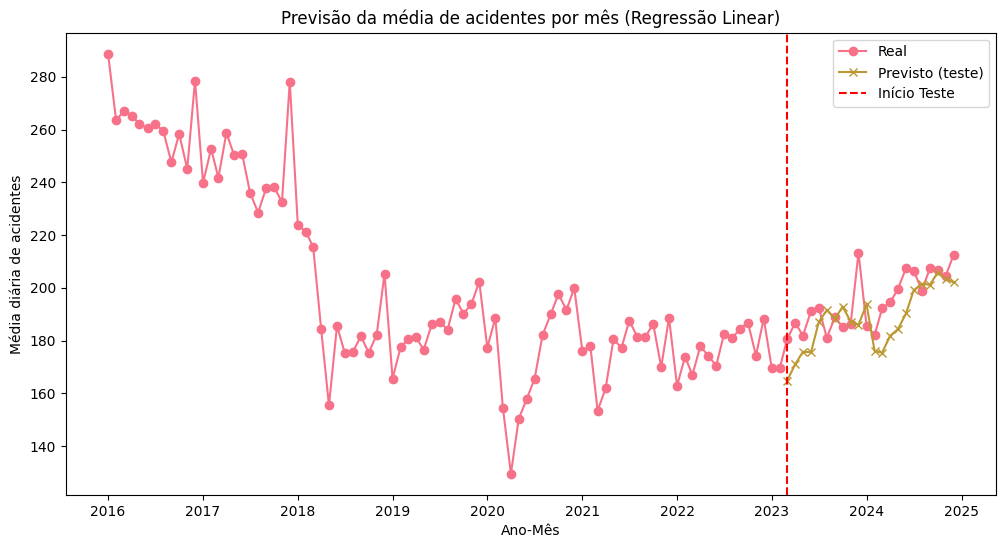

In [ ]:
# ===============================
# 1. Pré-processamento mensal
# ===============================

df['mes'] = df['data_inversa'].dt.month
df['dia_semana_num'] = df['data_inversa'].dt.dayofweek

df['hora'] = pd.to_datetime(df['horario'], errors='coerce').dt.hour
df['severidade'] = df['mortos'].apply(lambda x: 'Fatal' if x > 0 else 'Não Fatal')

# Criar coluna "ano_mes" para agrupar
df['ano_mes'] = df['data_inversa'].dt.to_period('M')

# Agregar os principais indicadores
df_mensal = df.groupby('ano_mes').agg({
    'id': 'count',  # número de acidentes
    'mortos': 'sum',
    'feridos_leves': 'sum',
    'feridos_graves': 'sum',
    'ilesos': 'sum',
    'veiculos': 'sum'
}).rename(columns={'id': 'total_acidentes'}).reset_index()

# Calcular a média diária de acidentes por mês
df_mensal['media_diaria'] = df_mensal['total_acidentes'] / df_mensal['ano_mes'].dt.days_in_month

# Proporção de acidentes fatais vs não fatais
df['fatal'] = (df['mortos'] > 0).astype(int)
df_fatais = df.groupby('ano_mes')['fatal'].mean().reset_index(name='prop_fatais')
df_mensal = df_mensal.merge(df_fatais, on='ano_mes', how='left')

# Proporção de acidentes em dias de chuva no mês
chuva = df[df['condicao_metereologica'] == 'Chuva'].groupby('ano_mes').size()
df_mensal['prop_chuva'] = chuva / df_mensal['total_acidentes']
df_mensal['prop_chuva'] = df_mensal['prop_chuva'].fillna(0)

# Converter ano_mes para datetime
df_mensal['ano_mes'] = df_mensal['ano_mes'].dt.to_timestamp()

# ===============================
# 2. Features
# ===============================

# Sazonalidade (sin/cos do mês)
df_mensal['mes'] = df_mensal['ano_mes'].dt.month
df_mensal['mes_sin'] = np.sin(2 * np.pi * df_mensal['mes'] / 12)
df_mensal['mes_cos'] = np.cos(2 * np.pi * df_mensal['mes'] / 12)

# Lags
df_mensal['lag1'] = df_mensal['media_diaria'].shift(1)
df_mensal['lag3'] = df_mensal['media_diaria'].shift(3).rolling(3).mean()
df_mensal['lag12'] = df_mensal['media_diaria'].shift(12)

# Remover NaNs criados pelos lags
df_model = df_mensal.dropna().copy()

# ===============================
# 3. Treino e Teste (time split)
# ===============================

# Features e target
X = df_model[['mes_sin', 'mes_cos', 'lag1', 'lag3', 'lag12']]
y = df_model['media_diaria']

# Separar treino (até 2022) e teste (2023–2024, por ex.)
train_size = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# ===============================
# 4. Treinar modelo
# ===============================

model = LinearRegression()
model.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred = model.predict(X_test)

# ===============================
# 5. Avaliação
# ===============================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# ===============================
# 6. Previsão do próximo mês
# ===============================

# Pegar último registro conhecido
ultimo = df_model.iloc[-1].copy()

# Criar linha de features para o próximo mês
proximo_mes = ultimo['ano_mes'] + pd.DateOffset(months=1)
mes_num = proximo_mes.month

features_novo = pd.DataFrame([{
    'mes_sin': np.sin(2 * np.pi * mes_num / 12),
    'mes_cos': np.cos(2 * np.pi * mes_num / 12),
    'lag1': ultimo['media_diaria'],
    'lag3': df_model['media_diaria'].iloc[-3:].mean(),
    'lag12': df_model[df_model['ano_mes'] == proximo_mes - pd.DateOffset(years=1)]['media_diaria'].values[0]
}])

# Previsão
previsao = model.predict(features_novo)[0]
print(f"\n✅ Previsão da média diária para {proximo_mes.strftime('%Y-%m')}: {previsao:.2f} acidentes/dia")

# ===============================
# 7. Visualização
# ===============================

plt.figure(figsize=(12,6))
plt.plot(df_model['ano_mes'], y, label='Real', marker='o')
plt.plot(df_model['ano_mes'].iloc[train_size:], y_pred, label='Previsto (teste)', marker='x')
plt.axvline(df_model['ano_mes'].iloc[train_size], color='red', linestyle='--', label='Início Teste')
plt.title("Previsão da média de acidentes por mês (Regressão Linear)")
plt.xlabel("Ano-Mês")
plt.ylabel("Média diária de acidentes")
plt.legend()
plt.show()

In [ ]:
df_mensal

,ano_mes,total_acidentes,mortos,feridos_leves,feridos_graves,ilesos,veiculos,media_diaria,prop_fatais,prop_chuva,mes,mes_sin,mes_cos,lag1,lag3,lag12
0,2015-01-01,12230,607,6168,1977,17902,21665,394.516129,0.038103,0.0,1,5.000000e-01,8.660254e-01,NaN,NaN,NaN
1,2015-02-01,11422,497,5320,1832,16033,19745,407.928571,0.036333,0.0,2,8.660254e-01,5.000000e-01,394.516129,NaN,NaN
2,2015-03-01,12448,614,5741,1921,16785,21452,401.548387,0.039926,0.0,3,1.000000e+00,6.123234e-17,407.928571,NaN,NaN
3,2015-04-01,12064,540,5777,1833,17012,21306,402.133333,0.037052,0.0,4,8.660254e-01,-5.000000e-01,401.548387,NaN,NaN
4,2015-05-01,12709,611,6040,1977,17550,22193,409.967742,0.039421,0.0,5,5.000000e-01,-8.660254e-01,402.133333,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-08-01,6167,546,5363,1668,6599,12517,198.935484,0.075726,0.0,8,-8.660254e-01,-5.000000e-01,206.483871,195.403226,181.064516
116,2024-09-01,6222,532,5309,1670,6333,12359,207.400000,0.074253,0.0,9,-1.000000e+00,-1.836970e-16,198.935484,200.516129,188.800000
117,2024-10-01,6406,493,5715,1806,6537,12712,206.645161,0.065876,0.0,10,-8.660254e-01,5.000000e-01,207.400000,204.510753,185.161290
118,2024-11-01,6135,510,5442,1709,6345,12130,204.500000,0.071394,0.0,11,-5.000000e-01,8.660254e-01,206.645161,204.306452,186.400000


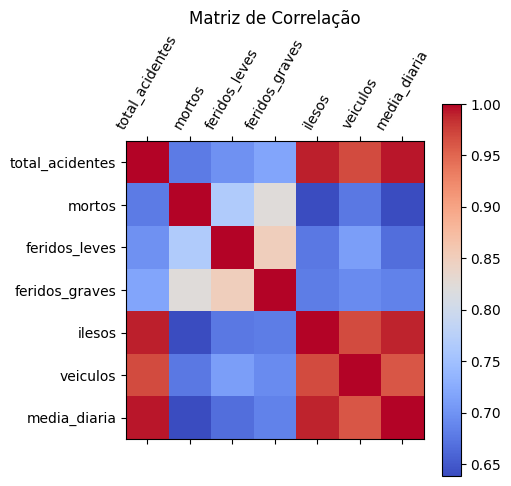

In [ ]:
# Selecione apenas colunas numéricas para análise de correlação
numeric_df = df_mensal.select_dtypes(include=['number'])
numeric_df = numeric_df.iloc[:, :-8]

# Matriz de correlação
corr = numeric_df.corr()

# matshow é usada para visualizar matrizes como uma imagem em cores
plt.matshow(corr, cmap="coolwarm")

plt.colorbar() # Exibe a barra lateral de cores

# Colocando os nomes das variáveis nos eixos
ticks = range(len(corr.columns))
plt.xticks(ticks, corr.columns, rotation=60)  # Eixo X
plt.yticks(ticks, corr.columns)               # Eixo Y

# Vizualizando a matriz de correlação
plt.title("Matriz de Correlação")
plt.show()

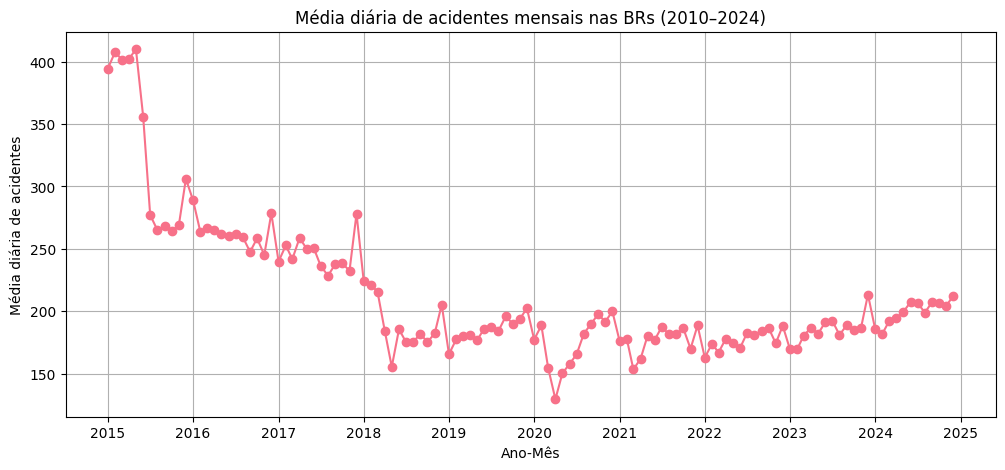

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                       media_diaria   No. Observations:                   96
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -355.238
Date:                            Wed, 29 Oct 2025   AIC                            720.477
Time:                                    14:02:41   BIC                            732.571
Sample:                                01-01-2015   HQIC                           725.335
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9460      0.183     -5.167      0.000      -1.305      -0.587
ma.L1          0.9996      8.350   

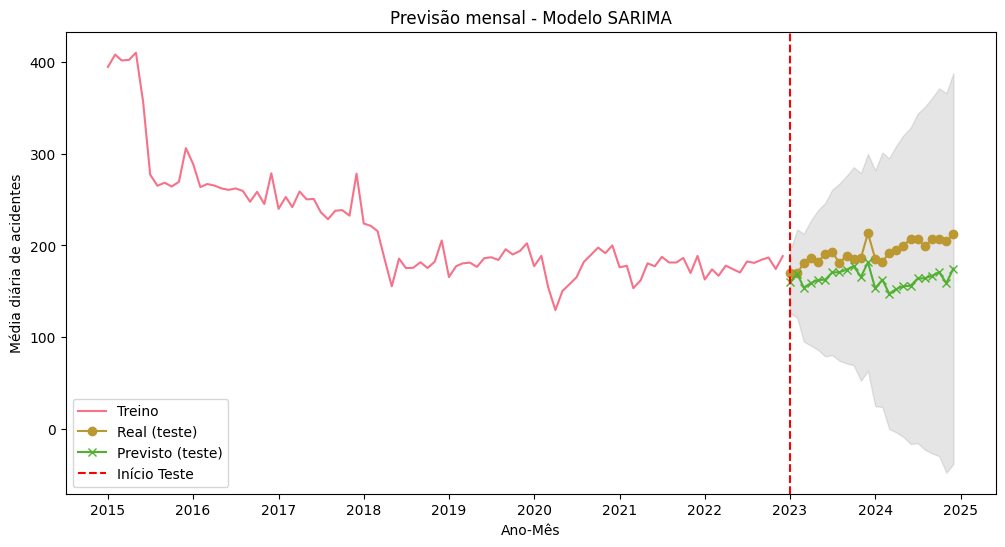


✅ Previsão da média diária para 2025-01: 160.09 acidentes/dia
Intervalo de confiança: [126.70, 193.47]


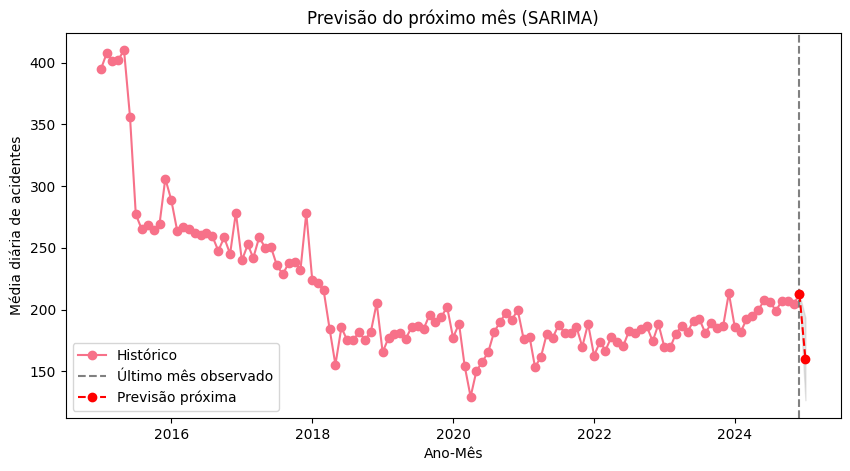

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===============================
# 1. Preparar a série temporal
# ===============================

df['ano_mes'] = df['data_inversa'].dt.to_period('M')
df_mensal = df.groupby('ano_mes').agg({
    'id': 'count',
    'mortos': 'sum',
    'feridos_leves': 'sum',
    'feridos_graves': 'sum',
    'ilesos': 'sum',
    'veiculos': 'sum'
}).rename(columns={'id': 'total_acidentes'}).reset_index()

df_mensal['media_diaria'] = df_mensal['total_acidentes'] / df_mensal['ano_mes'].dt.days_in_month
df_mensal['ano_mes'] = df_mensal['ano_mes'].dt.to_timestamp()

# Define o índice temporal
df_mensal = df_mensal.set_index('ano_mes')
serie = df_mensal['media_diaria']

# ===============================
# 2. Visualização inicial
# ===============================

plt.figure(figsize=(12,5))
plt.plot(serie, marker='o')
plt.title("Média diária de acidentes mensais nas BRs (2010–2024)")
plt.xlabel("Ano-Mês")
plt.ylabel("Média diária de acidentes")
plt.grid(True)
plt.show()

# ===============================
# 3. Divisão treino/teste
# ===============================
train_size = int(len(serie) * 0.8)
train, test = serie.iloc[:train_size], serie.iloc[train_size:]

# ===============================
# 4. Ajustar modelo SARIMA
# ===============================
# Ordem (p,d,q) e sazonal (P,D,Q,12)
# Dado que há sazonalidade anual, o 12 representa 12 meses

model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit(disp=False)

print(results.summary())

# ===============================
# 5. Previsões no conjunto de teste
# ===============================
pred = results.get_prediction(start=test.index[0], end=test.index[-1])
pred_mean = pred.predicted_mean
pred_conf = pred.conf_int()

# Métricas
mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))
print(f"\nMAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# ===============================
# 6. Visualizar previsão vs real
# ===============================
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Treino')
plt.plot(test.index, test, label='Real (teste)', marker='o')
plt.plot(pred_mean.index, pred_mean, label='Previsto (teste)', marker='x')
plt.fill_between(pred_conf.index, pred_conf.iloc[:,0], pred_conf.iloc[:,1], color='gray', alpha=0.2)
plt.axvline(test.index[0], color='red', linestyle='--', label='Início Teste')
plt.title("Previsão mensal - Modelo SARIMA")
plt.xlabel("Ano-Mês")
plt.ylabel("Média diária de acidentes")
plt.legend()
plt.show()

# ===============================
# 7. Previsão do próximo mês
# ===============================
forecast = results.get_forecast(steps=1)
mean_forecast = forecast.predicted_mean.iloc[0]
conf_int = forecast.conf_int().iloc[0]

proximo_mes = serie.index[-1] + pd.DateOffset(months=1)
print(f"\n✅ Previsão da média diária para {proximo_mes.strftime('%Y-%m')}: {mean_forecast:.2f} acidentes/dia")
print(f"Intervalo de confiança: [{conf_int[0]:.2f}, {conf_int[1]:.2f}]")

# ===============================
# 8. Visualizar previsão futura
# ===============================
plt.figure(figsize=(10,5))
plt.plot(serie, label='Histórico', marker='o')
plt.axvline(serie.index[-1], color='gray', linestyle='--', label='Último mês observado')
plt.plot([serie.index[-1], proximo_mes], [serie.iloc[-1], mean_forecast], 'r--o', label='Previsão próxima')
plt.fill_between([serie.index[-1], proximo_mes], [serie.iloc[-1], conf_int[0]], [serie.iloc[-1], conf_int[1]], color='gray', alpha=0.2)
plt.title("Previsão do próximo mês (SARIMA)")
plt.xlabel("Ano-Mês")
plt.ylabel("Média diária de acidentes")
plt.legend()
plt.show()
